In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# -------- USER SETTINGS --------
CAMERA_ID = 1
CALIB_NPZ = f"camera_data/camera{CAMERA_ID}/stereo_calib_charuco.npz"
name="shared"
LEFT_IMG  = f"camera_data/camera{CAMERA_ID}/output/{name}{CAMERA_ID}_left.png"
RIGHT_IMG = f"camera_data/camera{CAMERA_ID}/output/{name}{CAMERA_ID}_right.png"
# LEFT_IMG  = "calib\\left_09.png"
# RIGHT_IMG = "calib\\right_09.png"

OUT_PREFIX = f"processed/{name}{CAMERA_ID}"

# Stereo matcher parameters
DEPTH_MIN_M = 0.01
DEPTH_MAX_M = 0.25
# -------------------------------


# ---- Load calibration ----
data = np.load(CALIB_NPZ, allow_pickle=True)

image_size = tuple(data["image_size"])
mapLx, mapLy = data["mapLx"], data["mapLy"]
mapRx, mapRy = data["mapRx"], data["mapRy"]
Q = data["Q"]


FileNotFoundError: [Errno 2] No such file or directory: 'camera_data/camera1/stereo_calib_charuco.npz'

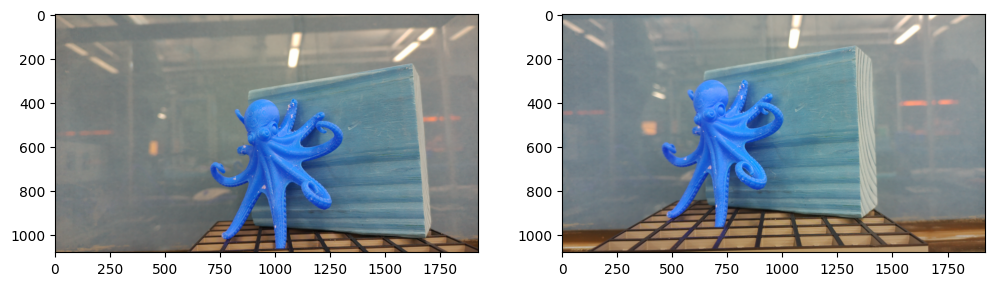

In [20]:
# ---- Load images ----
imgL = cv2.imread(LEFT_IMG, cv2.IMREAD_COLOR)
imgR = cv2.imread(RIGHT_IMG, cv2.IMREAD_COLOR)

fig,ax=plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(imgL)
ax[1].imshow(imgR)

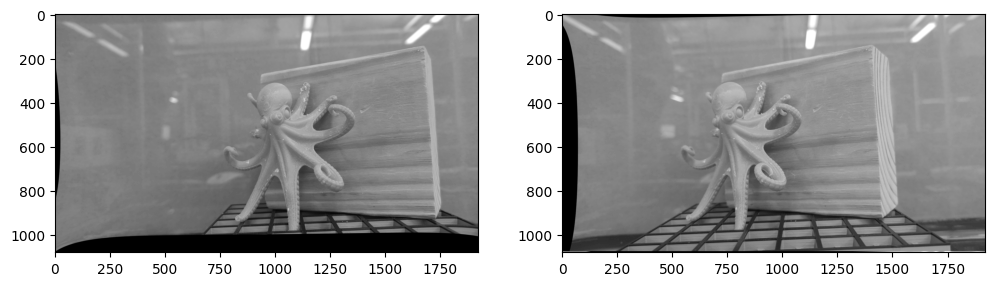

In [21]:
# ---- Rectify ----
#from check_rectify import stack_with_lines
rectL = cv2.remap(imgL, mapLx, mapLy, cv2.INTER_LINEAR)
rectR = cv2.remap(imgR, mapRx, mapRy, cv2.INTER_LINEAR)

# rolling the right image up by 4 pixels to better align with the left (based on visual inspection of epipolar lines)
rectR = np.roll(rectR, shift=-4, axis=0)

# ---- Convert to grayscale ----
grayL = cv2.cvtColor(rectL, cv2.COLOR_BGR2GRAY)
grayR = cv2.cvtColor(rectR, cv2.COLOR_BGR2GRAY)

#overlay = stack_with_lines(rectL, rectR, step=40)
fig,ax=plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(grayL,cmap="gray")
ax[1].imshow(grayR,cmap="gray")
# plt.figure(figsize=(12,6))
# plt.imshow(overlay)

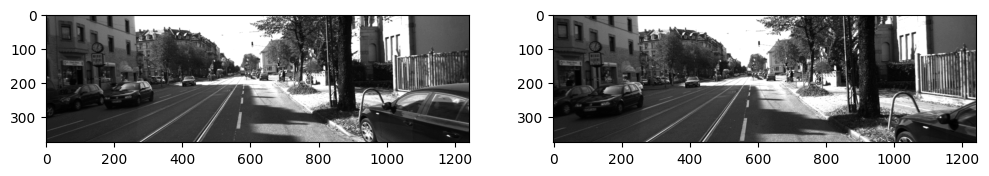

In [69]:
imgL = cv2.imread("000004_10.png", cv2.IMREAD_COLOR)
imgR = cv2.imread("000004_11.png", cv2.IMREAD_COLOR)

grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

fig,ax=plt.subplots(1,2, figsize=(12,6))
ax[0].imshow(grayL,cmap="gray")
ax[1].imshow(grayR,cmap="gray")

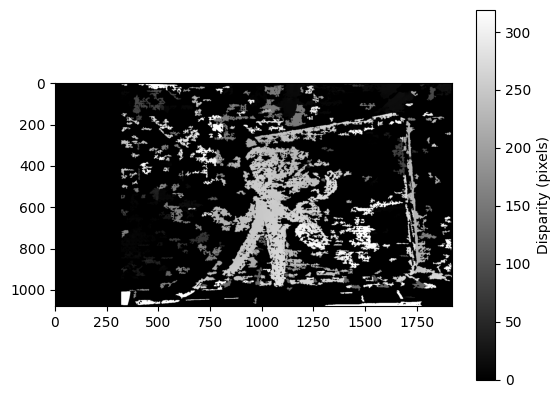

In [27]:
# ---- Stereo disparity ----
BLOCK_SIZE =5      # odd: 5,7,9...
stereo = cv2.StereoSGBM_create(
    minDisparity=0,
    numDisparities= 16 *20,   # must be multiple of 16,
    blockSize=BLOCK_SIZE,
    P1=8 * BLOCK_SIZE * BLOCK_SIZE,
    P2=32 * BLOCK_SIZE * BLOCK_SIZE,
    disp12MaxDiff=-1,
    uniquenessRatio=1,
    speckleWindowSize=200,
    speckleRange=1,
    preFilterCap = 63,
    mode=cv2.STEREO_SGBM_MODE_SGBM,
)
disp = stereo.compute(grayL, grayR).astype(np.float32) / 16.0
disp[disp < 0] = np.nan   # invalid disparity to NaN
disp = np.nan_to_num(disp, nan=0.0).astype(np.float32)
plt.imshow(disp, cmap="gray")
plt.colorbar(label="Disparity (pixels)")



In [ ]:
wls = cv2.ximgproc.createDisparityWLSFilter(matcher_left=stereo)

# Typical good starting values:
# lambda: smoothness strength (higher = smoother, less noise, more bleeding)
# sigmaColor: edge sensitivity (higher = edges preserved more strongly)
wls.setLambda(8000)        # try 5000, 8000, 12000, 20000
wls.setSigmaColor(1.5)     # try 0.8 - 2.0

